## Importando as Bibliotecas

In [1]:
# Manipulação e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos estatísticos
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Validação e tuning
from sklearn.model_selection import (
    TimeSeriesSplit,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve
)

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor

import optuna
import optuna.visualization as viz

import shap

print("Bibliotecas importadas com sucesso!")

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\energy-demand-forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas importadas com sucesso!


# 1. Leitura e Validação dos Dados

In [2]:
# Leitura, transformação em datetime e modificando o index
dados = pd.read_csv("../data/dados_tratados.csv")
dados["data_hora"] = pd.to_datetime(dados["data_hora"], format="%Y-%m-%d %H:%M:%S")
dados = dados.set_index("data_hora")
dados = dados.drop(columns=["consumo_zona_2", "consumo_zona_3"])
dados.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1
data_hora,,,,,,
2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620
2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354
2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127
2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076
2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620


In [3]:
print(f"Classe do Index -> {type(dados.index)}")
print(f"Shape -> {dados.shape}")

print(f"\nValores Ausentes -> {dados.isna().sum().sum()}")

print(f"\nOrdenado -> {dados.index.is_monotonic_increasing}")
print(f"\nFrequência -> {pd.infer_freq(dados.index)}")

print(f"\nPeríodo -> {dados.index.min().date()} até {dados.index.max().date()}")

Classe do Index -> <class 'pandas.DatetimeIndex'>
Shape -> (52416, 6)

Valores Ausentes -> 0

Ordenado -> True

Frequência -> 10min

Período -> 2017-01-01 até 2017-12-30


# 2. Divisão dos Dados de Modelagem e Teste Final

In [4]:
um_mes = 4320

dados_modelagem = dados.iloc[:-um_mes].copy()
teste_final = dados.iloc[-um_mes:].copy()

Dados Modelagem -> 2017-01-01 até 2017-11-30
Teste Final -> 2017-12-01 até 2017-12-30


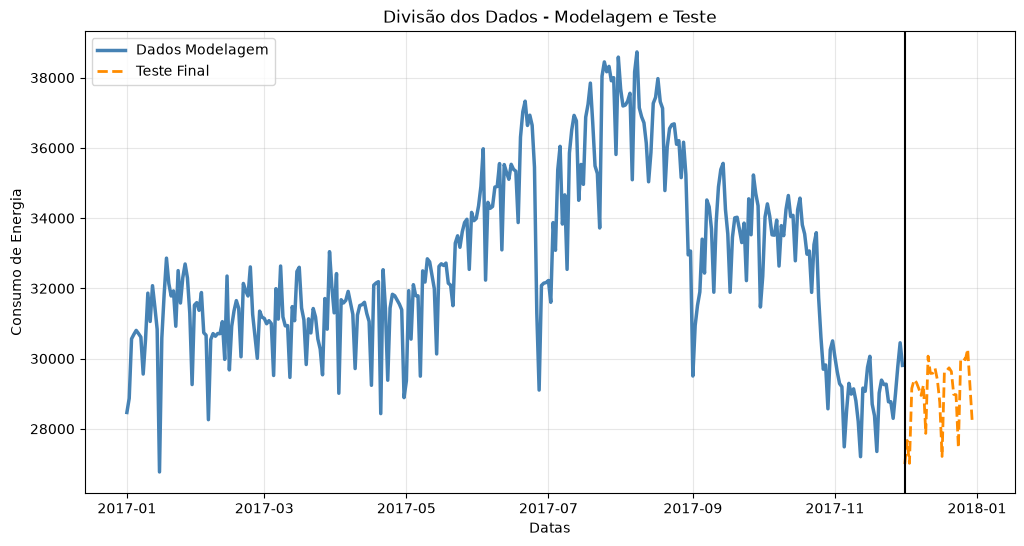

In [5]:
print(f"Dados Modelagem -> {dados_modelagem.index.min().date()} até {dados_modelagem.index.max().date()}")
print(f"Teste Final -> {teste_final.index.min().date()} até {teste_final.index.max().date()}")

modelagem_diaria = dados_modelagem["consumo_zona_1"].resample("D").mean()
teste_diaria = teste_final["consumo_zona_1"].resample("D").mean()

plt.figure(figsize=(12,6))

plt.plot(modelagem_diaria.index, modelagem_diaria, color="steelblue", linewidth=2.5, label="Dados Modelagem")
plt.plot(teste_diaria.index, teste_diaria, color="darkorange", linewidth=2.0 ,linestyle='--', label="Teste Final")
plt.axvline(teste_diaria.index[0], color='black', linewidth=1.5)
plt.title("Divisão dos Dados - Modelagem e Teste")
plt.xlabel("Datas")
plt.ylabel("Consumo de Energia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Definição das Métricas

In [6]:
def calcula_metricas(y_real, previsto):
    mae = mean_absolute_error(y_real, previsto)
    rmse = np.sqrt(mean_squared_error(y_real, previsto))
    mape = mean_absolute_percentage_error(y_real, previsto)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

# 4. Modelos Estatísticos

## 4.1 Holt-Winters

In [7]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_hw = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(dados_modelagem), start=1):

    treino = dados_modelagem.iloc[train_idx]["consumo_zona_1"]
    validacao = dados_modelagem.iloc[val_idx]["consumo_zona_1"]

    modelo = ExponentialSmoothing(
        treino,
        trend='add',
        seasonal='add',
        seasonal_periods=144
    ).fit()

    previsoes = modelo.forecast(steps=len(validacao))

    metricas = calcula_metricas(validacao, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Holt-Winters"

    resultados_hw.append(metricas)

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency 10min will be used.
  self._init_dates(dates, freq)
c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\energy-demand-forecasting\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided

# 5. Modelos de Machine Learning

## 5.1 - Preparação dos Dados para Machine Learning

In [8]:
dados_ml = dados.copy()
target = "consumo_zona_1"

# Lags
dados_ml["lag_1"] = dados_ml[target].shift(1) # 10 min
dados_ml["lag_6"] = dados_ml[target].shift(6) # 1 hora
dados_ml["lag_144"] = dados_ml[target].shift(144) # 1 dia
dados_ml["lag_1008"] = dados_ml[target].shift(1008) # 1 semana

# Médias Móveis
dados_ml["rolling_mean_6"] = dados_ml[target].shift(1).rolling(6).mean()
dados_ml["rolling_mean_144"] = dados_ml[target].shift(1).rolling(144).mean()

# Variáveis Temporais
dados_ml["hora"] = dados_ml.index.hour
dados_ml["dia_da_semana"] = dados_ml.index.dayofweek

# Representação cíclica da hora
dados_ml["hora_sin"] = np.sin(2 * np.pi * dados_ml["hora"] / 24)

dados_ml["hora_cos"] = np.cos(2 * np.pi * dados_ml["hora"] / 24)

# Removendo columa de hora
dados_ml.drop(columns=["hora"], inplace=True)

# Removendo valores nulos
dados_ml = dados_ml.dropna()

In [9]:
dados_ml.head()

,temperatura,umidade,velocidade_vento,fluxo_difuso_geral,fluxo_difuso,consumo_zona_1,lag_1,lag_6,lag_144,lag_1008,rolling_mean_6,rolling_mean_144,dia_da_semana,hora_sin,hora_cos
data_hora,,,,,,,,,,,,,,,
2017-01-08 00:00:00,14.07,78.2,0.081,0.048,0.130,28332.15190,29401.51899,33812.65823,28927.59494,34055.69620,31526.075950,30612.700422,6,0.0,1.0
2017-01-08 00:10:00,14.19,77.8,0.085,0.044,0.111,27791.39241,28332.15190,32955.94937,28052.65823,29814.68354,30612.658228,30608.565401,6,0.0,1.0
2017-01-08 00:20:00,14.27,77.7,0.087,0.033,0.122,26831.39241,27791.39241,31868.35443,27220.25316,29128.10127,29751.898735,30606.751055,6,0.0,1.0
2017-01-08 00:30:00,14.34,77.7,0.092,0.055,0.134,26296.70886,26831.39241,30914.43038,26831.39241,28228.86076,28912.405065,30604.050633,6,0.0,1.0
2017-01-08 00:40:00,14.37,77.9,0.089,0.040,0.137,25585.82278,26296.70886,30203.54430,26363.54430,27335.69620,28142.784812,30600.337552,6,0.0,1.0


## 5.2 - Preparação dos Dados para Modelagem e Teste Final

In [10]:
data_inicio_teste = teste_final.index.min()
print(data_inicio_teste)

2017-12-01 00:00:00


In [11]:
dados_ml_modelagem = dados_ml.iloc[dados_ml.index < data_inicio_teste].copy()
teste_ml_final = dados_ml.iloc[dados_ml.index > data_inicio_teste].copy()

print(f"Dados ML Modelagem -> {dados_ml_modelagem.index.min().date()} até {dados_ml_modelagem.index.max().date()}")
print(f"Teste ML Final -> {teste_ml_final.index.min().date()} até {teste_ml_final.index.max().date()}")

Dados ML Modelagem -> 2017-01-08 até 2017-11-30
Teste ML Final -> 2017-12-01 até 2017-12-30


In [12]:
FEATURES = ['temperatura', 'umidade', 'velocidade_vento', 'fluxo_difuso_geral',
            'fluxo_difuso', 'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'rolling_mean_6',
            'rolling_mean_144', 'dia_da_semana', 'hora_sin', 'hora_cos']

X_modelagem = dados_ml_modelagem[FEATURES]
y_modelagem = dados_ml_modelagem["consumo_zona_1"]

X_teste_final = teste_ml_final[FEATURES]
y_teste_final = teste_ml_final["consumo_zona_1"]

## 5.3 - Modelo Random Forest

In [13]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_rf = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = RandomForestRegressor(
        n_estimators=300,
        max_depth=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "Random Forest"

    resultados_rf.append(metricas)

## 5.4 - Modelo XGBoost

In [14]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_xgb = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo_xgb = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=5,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost"

    resultados_xgb.append(metricas)

## 5.5 - Modelo LightGBM

In [15]:
tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=4320
)

resultados_gbm = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "LightGBM"

    resultados_gbm.append(metricas) 

# 6. Comparação Inicial dos Modelos

In [16]:
df_hw = pd.DataFrame(resultados_hw)
df_rf = pd.DataFrame(resultados_rf)
df_xgb = pd.DataFrame(resultados_xgb)
df_gbm = pd.DataFrame(resultados_gbm)

resultados = pd.concat([df_hw, df_rf, df_xgb, df_gbm])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3)
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)
comparacao

MAE                    RMSE                MAPE        
                     mean         std        mean         std    mean     std
Modelo                                                                       
LightGBM          317.738      89.830     474.251     134.642   0.010   0.002
Random Forest     495.382      97.251     710.278     148.177   0.015   0.002
XGBoost           495.382      97.251     710.278     148.177   0.015   0.002
Holt-Winters   344724.181  327708.790  397883.791  378224.962  11.439  11.176

# 7. Otimiazação de Hiperparãmetros - RandomSearchCV

In [17]:
modelo_xgb = xgb.XGBRegressor(ojective="reg:absoluteerror", random_state=42, n_jobs=-1)

parametros_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [5, 7, 9],
    "min_child_weight": [1, 3, 5],
    "subsample": [ 0.9, 1.0],
    "colsample_bytree": [ 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

busca_xgb = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=parametros_xgb,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

busca_xgb.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparametros -> {busca_xgb.best_params_}")
print(f"Melhor Resultado MAE -> {-busca_xgb.best_score_}")

c:\Users\Unisalesiano\Documents\Renan\Projetos Renan\energy-demand-forecasting\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [09:34:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "ojective" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Melhores Hiperparametros -> {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Melhor Resultado MAE -> 294.95312335325525


In [18]:
modelo_gbm = LGBMRegressor(objective="regression", random_state=42, n_jobs=1, verbosity=-1)

parametros_lgbm = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [5, 7, 10],
    "min_child_samples": [10, 20, 30],
    "subsample": [0.9, 1.0],
    "colsample_bytree": [0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 1, 5, 10]
}

busca_gbm = RandomizedSearchCV(
    estimator=modelo_gbm,
    param_distributions=parametros_lgbm,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

busca_gbm.fit(X_modelagem, y_modelagem)

print(f"Melhores Hiperparâmetros -> {busca_gbm.best_params_}")
print(f"Melhor Resultado MAE -> {-busca_gbm.best_score_}")

Melhores Hiperparâmetros -> {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Melhor Resultado MAE -> 296.2666129431808


# 8. Avaliação dos Modelos Otimizados

In [19]:
resultados_xgb_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(**busca_xgb.best_params_, objective="reg:squarederror", random_state=42, n_jobs=-1)

    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Tunnado"

    resultados_xgb_tuned.append(metricas)

In [20]:
resultados_gbm_tuned = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):

    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = LGBMRegressor(**busca_gbm.best_params_, objective="regression", random_state=42, n_jobs=1, verbosity=-1)

    modelo.fit(X_treino, y_treino)
    previsoes = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, previsoes)

    metricas["Fold"] = fold
    metricas["Modelo"] = "LightGBM Tunnado"

    resultados_gbm_tuned.append(metricas)

## 8.1 - Comparação Final dos Modelos

In [21]:
df_xgb_tunado = pd.DataFrame(resultados_xgb_tuned)
df_gbm_tunado = pd.DataFrame(resultados_gbm_tuned)

resultados = pd.concat([resultados, df_xgb_tunado, df_gbm_tunado])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"]).round(3)
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)

In [22]:
comparacao = comparacao.drop(index="Holt-Winters")
comparacao

MAE             RMSE            MAPE       
                     mean     std     mean      std   mean    std
Modelo                                                           
XGBoost Tunnado   295.150  83.547  455.003  133.603  0.009  0.002
LightGBM Tunnado  296.267  84.126  450.788  130.321  0.009  0.002
LightGBM          317.738  89.830  474.251  134.642  0.010  0.002
Random Forest     495.382  97.251  710.278  148.177  0.015  0.002
XGBoost           495.382  97.251  710.278  148.177  0.015  0.002

# 9. Otimização do XGBoost com Optuna

In [23]:
tscv = TimeSeriesSplit(n_splits=5, test_size=4320)

def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 400, 1000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.85, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.85, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0)
    }

    modelo = xgb.XGBRegressor(**params, objective="reg:squarederror", tree_method="hist", random_state=42, n_jobs=1)

    score = cross_val_score(modelo, X_modelagem, y_modelagem, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1).mean()

    return -score

In [24]:
sampler = optuna.samplers.TPESampler(seed=42)

study_xgb = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study_xgb.optimize(
    objective_xgb,
    n_trials=20
)

[I 2026-09-15 09:36:32,374] A new study created in memory with name: no-name-d672c462-d710-4dde-8b33-597b471d2cd7


[I 2026-09-15 09:36:52,149] Trial 0 finished with value: 315.50940898725406 and parameters: {'n_estimators': 600, 'learning_rate': 0.07220721098226064, 'max_depth': 9, 'min_child_weight': 5, 'subsample': 0.8734027960663655, 'colsample_bytree': 0.8733991780504303, 'reg_alpha': 0.00017775399007348227, 'reg_lambda': 9.515184190867908, 'gamma': 1.2022300234864176}. Best is trial 0 with value: 315.50940898725406.
[I 2026-09-15 09:37:33,167] Trial 1 finished with value: 305.9091615870515 and parameters: {'n_estimators': 850, 'learning_rate': 0.010437335666720523, 'max_depth': 10, 'min_child_weight': 7, 'subsample': 0.8818508666017414, 'colsample_bytree': 0.877273745081065, 'reg_alpha': 0.000614933705708711, 'reg_lambda': 1.4072546358030324, 'gamma': 1.0495128632644757}. Best is trial 1 with value: 305.9091615870515.
[I 2026-09-15 09:37:51,830] Trial 2 finished with value: 304.2001471112847 and parameters: {'n_estimators': 650, 'learning_rate': 0.0183234024502698, 'max_depth': 8, 'min_child_w

In [25]:
print(f"Melhor MAE -> {study_xgb.best_value:.4f}")

print(f"Melhores Hiperparâmetros -> {study_xgb.best_params}")

Melhor MAE -> 296.5647
Melhores Hiperparâmetros -> {'n_estimators': 800, 'learning_rate': 0.01803615730939571, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.8682133194282042, 'colsample_bytree': 0.9991105289762969, 'reg_alpha': 0.04982647798658546, 'reg_lambda': 11.535091545257742, 'gamma': 0.8338003133269434}


In [26]:
fig1 = viz.plot_optimization_history(study_xgb, target_name="MAE")
fig1.show()

fig2 = viz.plot_param_importances(study_xgb, target_name="MAE")
fig2.show()

In [27]:
tscv = TimeSeriesSplit(n_splits=5, test_size=4320)

resultado_xgb_optuna = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modelagem), start=1):
    X_treino = X_modelagem.iloc[train_idx]
    X_val = X_modelagem.iloc[val_idx]

    y_treino = y_modelagem.iloc[train_idx]
    y_val = y_modelagem.iloc[val_idx]

    modelo = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)

    modelo.fit(X_treino, y_treino)

    pred = modelo.predict(X_val)

    metricas = calcula_metricas(y_val, pred)

    metricas["Fold"] = fold
    metricas["Modelo"] = "XGBoost Optuna"

    resultado_xgb_optuna.append(metricas)

In [28]:
df_xgb_optuna = pd.DataFrame(resultado_xgb_optuna)
resultados = pd.concat([resultados, df_xgb_optuna])

comparacao = resultados.groupby("Modelo")[["MAE", "RMSE", "MAPE"]].agg(["mean", "std"])
comparacao = comparacao.sort_values(by=("MAE", "mean"), ascending=True)
comparacao

MAE                          RMSE                 \
                           mean            std           mean            std   
Modelo                                                                         
XGBoost Tunnado      295.149796      83.547333     455.002602     133.602700   
LightGBM Tunnado     296.266613      84.126082     450.787825     130.321492   
XGBoost Optuna       298.705493      89.843574     455.021574     139.541201   
LightGBM             317.737596      89.830464     474.251256     134.642482   
XGBoost              495.382395      97.250696     710.277637     148.177383   
Random Forest        495.382395      97.250696     710.277637     148.177383   
Holt-Winters      344724.181311  327708.789696  397883.790674  378224.962075   

                       MAPE             
                       mean        std  
Modelo                                  
XGBoost Tunnado    0.008961   0.001964  
LightGBM Tunnado   0.009005   0.001924  
XGBoost Optuna     0.009032   0.002032  
LightGBM           0.009693   0.002222  
XGBoost            0.014686   0.001896  
Random Forest      0.014686   0.001896  
Holt-Winters      11.438911  11.176354

In [29]:
comparacao = comparacao.drop(index="Holt-Winters")
comparacao

MAE                   RMSE                  MAPE  \
                        mean        std        mean         std      mean   
Modelo                                                                      
XGBoost Tunnado   295.149796  83.547333  455.002602  133.602700  0.008961   
LightGBM Tunnado  296.266613  84.126082  450.787825  130.321492  0.009005   
XGBoost Optuna    298.705493  89.843574  455.021574  139.541201  0.009032   
LightGBM          317.737596  89.830464  474.251256  134.642482  0.009693   
XGBoost           495.382395  97.250696  710.277637  148.177383  0.014686   
Random Forest     495.382395  97.250696  710.277637  148.177383  0.014686   

                            
                       std  
Modelo                      
XGBoost Tunnado   0.001964  
LightGBM Tunnado  0.001924  
XGBoost Optuna    0.002032  
LightGBM          0.002222  
XGBoost           0.001896  
Random Forest     0.001896

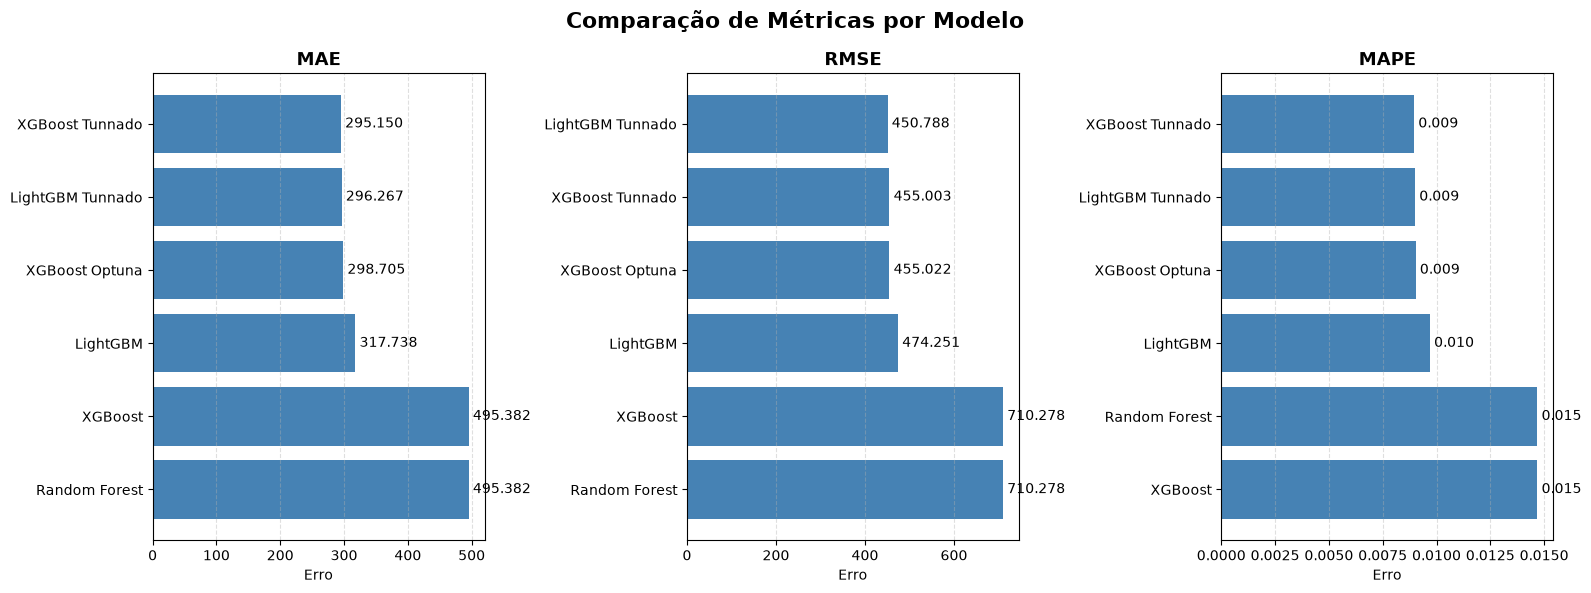

In [30]:
metricas_plot = pd.DataFrame({
    "MAE": comparacao[("MAE", "mean")],
    "RMSE": comparacao[("RMSE", "mean")],
    "MAPE": comparacao[("MAPE", "mean")]
})

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

metricas = ["MAE", "RMSE", "MAPE"]

for ax, metrica in zip(axes, metricas):

    valores = metricas_plot[metrica].sort_values(ascending=False)

    bars = ax.barh(valores.index, valores.values, color="steelblue")

    ax.set_title(metrica, fontsize=13, fontweight="bold")

    ax.set_xlabel("Erro")

    ax.grid(axis="x", linestyle="--", alpha=0.4)

    ax.bar_label(bars, fmt="%.3f", padding=3)

fig.suptitle("Comparação de Métricas por Modelo", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

# 10. Análise de Overfitting - Learning Curve

In [31]:
modelo_xgb_final = xgb.XGBRegressor(**busca_xgb.best_params_, random_state=42, n_jobs=-1)

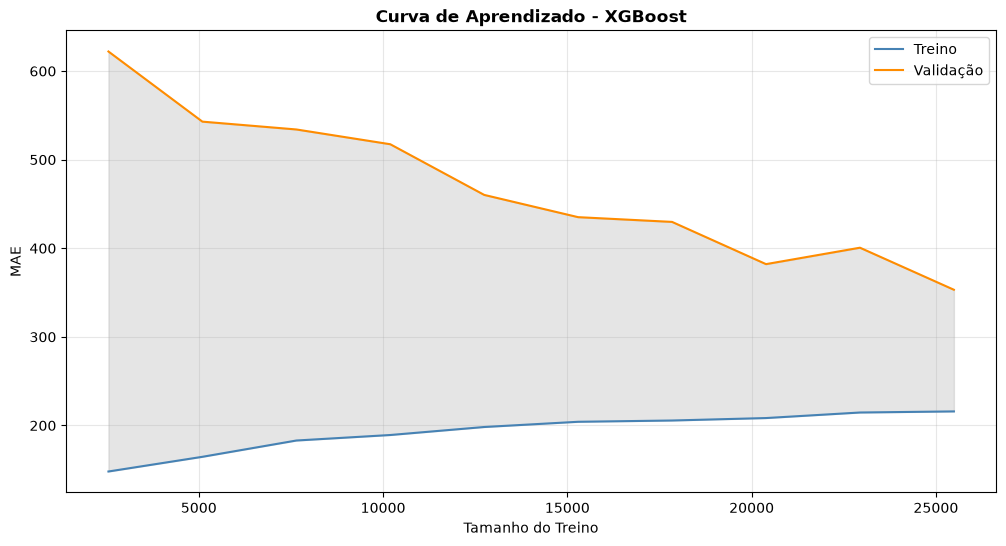

In [32]:
tscv = TimeSeriesSplit(n_splits=5, test_size=4320)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=modelo_xgb_final,
    X= X_modelagem,
    y= y_modelagem,
    cv=tscv,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

train_mean = -train_scores.mean(axis=1)
val_mean = -validation_scores.mean(axis=1)

plt.figure(figsize=(12, 6))

plt.plot(train_sizes, train_mean, label='Treino', color='steelblue')
plt.plot(train_sizes, val_mean, label='Validação', color='darkorange')
plt.fill_between(train_sizes, train_mean, val_mean, alpha=0.2, color="gray")

plt.title("Curva de Aprendizado - XGBoost",fontweight="bold")
plt.xlabel("Tamanho do Treino")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [33]:
gap_final = val_mean[-1] - train_mean[-1]

print(f"MAE - Treino: {train_mean[-1]:.4f}")
print(f"MAE - Validação: {val_mean[-1]:.4f}")
print(f"GAP Final -> {gap_final:.4f}")

MAE - Treino: 215.8581
MAE - Validação: 353.1835
GAP Final -> 137.3254


# 11. Avaliação Final - Conjunto de Teste

In [34]:
modelo_final = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1)

modelo_final.fit(X_modelagem, y_modelagem)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9991105289762969
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
previsoes_finais = modelo_final.predict(X_teste_final)

previsoes_finais = pd.Series(
    previsoes_finais,
    index=y_teste_final.index,
    name="previsao"
)

In [36]:
metricas_finais = calcula_metricas(y_teste_final, previsoes_finais)
metricas_finais_df = pd.DataFrame(metricas_finais, index=["XGBoost_final"])
metricas_finais_df

,MAE,RMSE,MAPE
XGBoost_final,211.883495,318.062942,0.007788


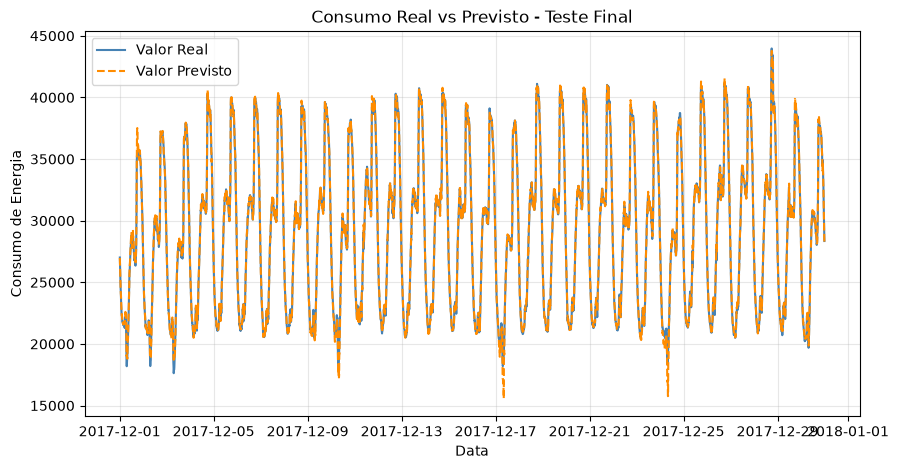

In [37]:
plt.figure(figsize=(10,5))

plt.plot(y_teste_final.index, y_teste_final, label="Valor Real", color='steelblue')
plt.plot(previsoes_finais.index, previsoes_finais, label="Valor Previsto", color='darkorange', linestyle='--')

plt.title("Consumo Real vs Previsto - Teste Final")
plt.xlabel("Data")
plt.ylabel("Consumo de Energia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

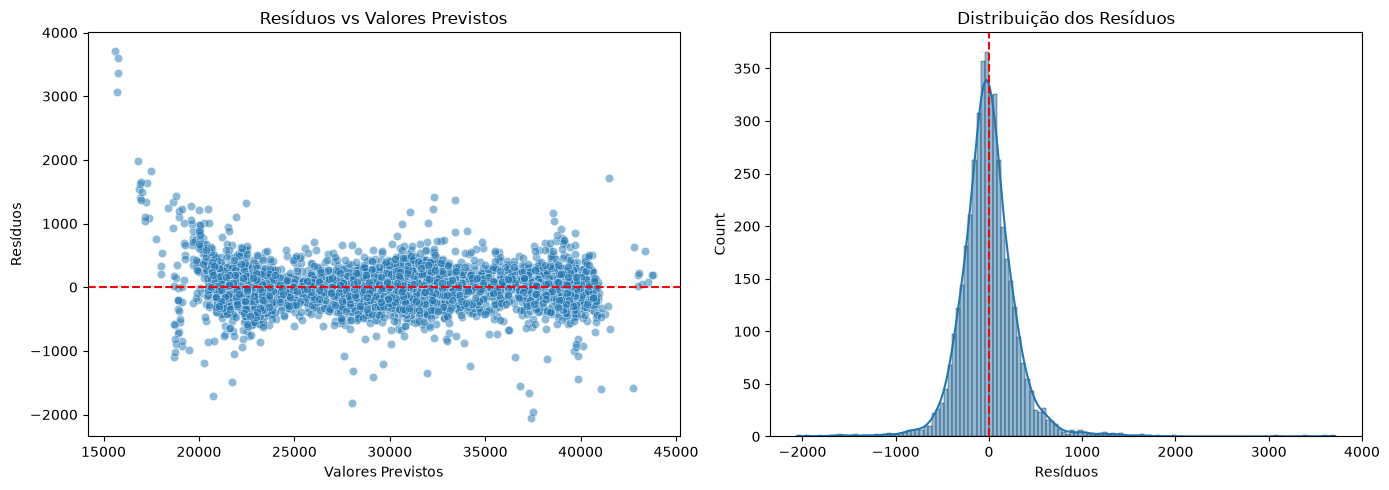

In [38]:
residuos = y_teste_final - previsoes_finais

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x=previsoes_finais, y=residuos, alpha=0.5, ax=axes[0])
axes[0].axhline(0.0, color='red', linestyle='--')
axes[0].set_title("Resíduos vs Valores Previstos")
axes[0].set_xlabel("Valores Previstos")
axes[0].set_ylabel("Resíduos")

sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].axvline(0.0, color='red', linestyle='--')
axes[1].set_title("Distribuição dos Resíduos")
axes[1].set_xlabel("Resíduos")

plt.tight_layout()
plt.show()

# 12. Importancia das Features

In [39]:
importance_xgb = pd.DataFrame({
    "feature": X_modelagem.columns,
    "importance": modelo_final.feature_importances_
})

importance_xgb = importance_xgb.sort_values(by="importance", ascending=False)
print(importance_xgb)

               feature  importance
5                lag_1    0.865592
9       rolling_mean_6    0.098206
7              lag_144    0.024588
8             lag_1008    0.003451
3   fluxo_difuso_geral    0.002443
13            hora_cos    0.001628
12            hora_sin    0.001340
6                lag_6    0.001109
4         fluxo_difuso    0.000636
10    rolling_mean_144    0.000371
11       dia_da_semana    0.000208
0          temperatura    0.000186
1              umidade    0.000122
2     velocidade_vento    0.000119


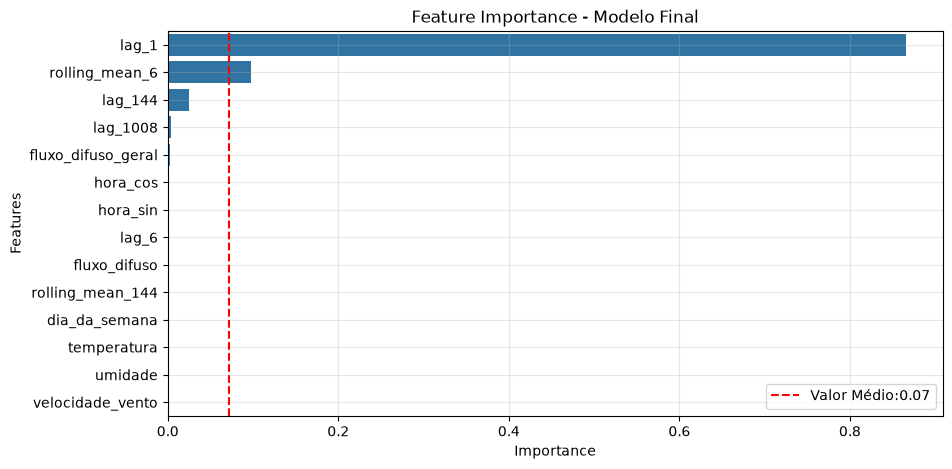

In [40]:
valor_medio = importance_xgb['importance'].mean()

plt.figure(figsize=(10,5))

sns.barplot(data=importance_xgb, x=importance_xgb['importance'], y=importance_xgb['feature'])
plt.axvline(importance_xgb["importance"].mean(), color="red", label=f"Valor Médio:{valor_medio:.2f}", linestyle='--')
plt.title("Feature Importance - Modelo Final")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 13. Interpretabilidade do modelo - SHAP

In [50]:
explainer = shap.TreeExplainer(modelo_final)

shap_values = explainer(X_teste_final)

## Importância Global das Variáveis

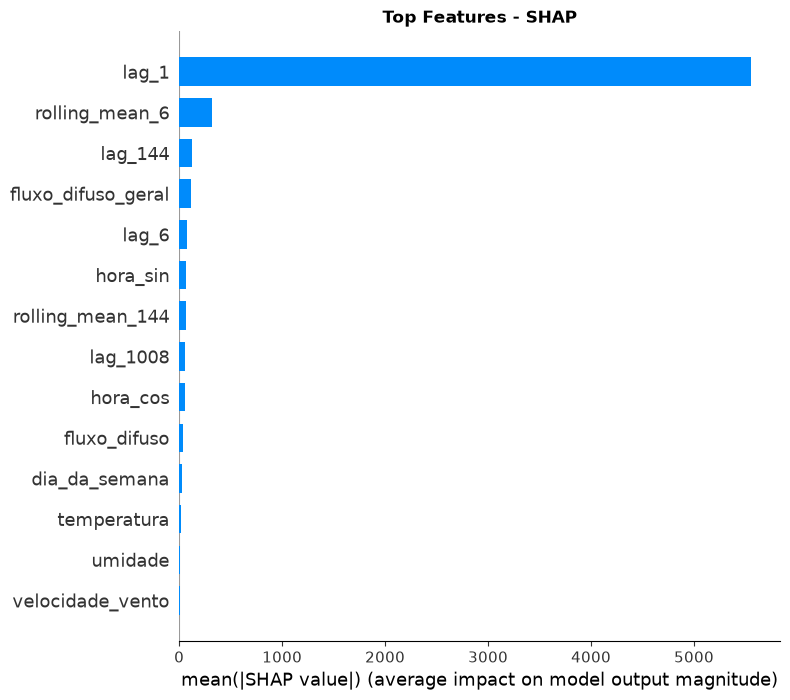

In [51]:
shap.summary_plot(
    shap_values,
    X_teste_final,
    plot_type='bar',
    show=False
)
plt.title("Top Features - SHAP", fontweight='bold')
plt.tight_layout()
plt.show()

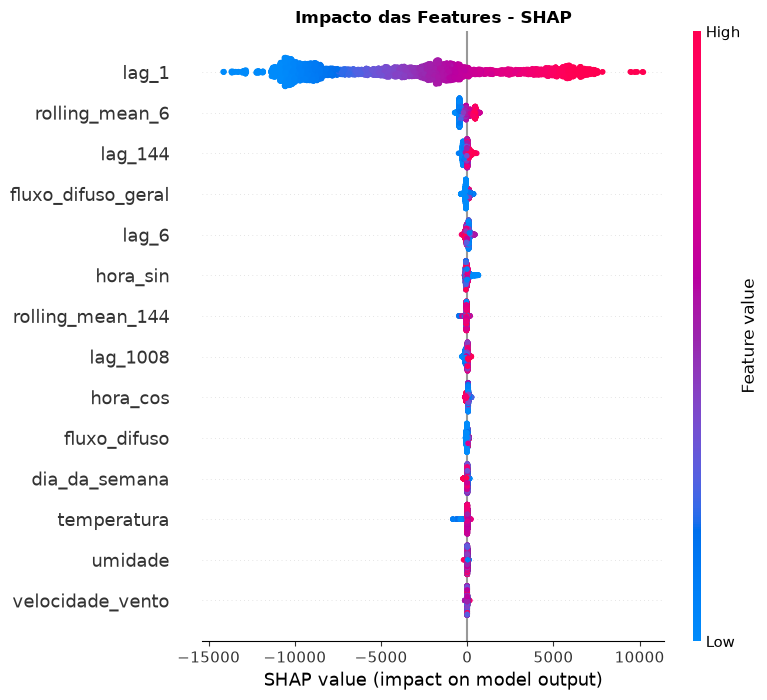

In [52]:
shap.summary_plot(
    shap_values,
    X_teste_final,
    show=False
)
plt.title("Impacto das Features - SHAP", fontweight='bold')
plt.tight_layout()
plt.show()

## Dependência do Lag 1

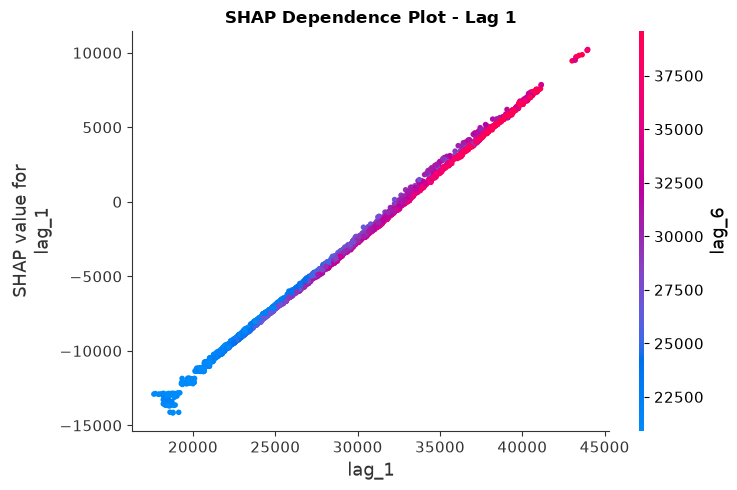

In [54]:
feature_dependence = "lag_1"

shap.dependence_plot(
    feature_dependence,
    shap_values.values,
    X_teste_final,
    show=False
)
plt.title("SHAP Dependence Plot - Lag 1", fontweight='bold')
plt.tight_layout()
plt.show()

## Explicação Individual de uma Previsão

Valor Real -> 25277.57
Valor Previsto -> 25385.79


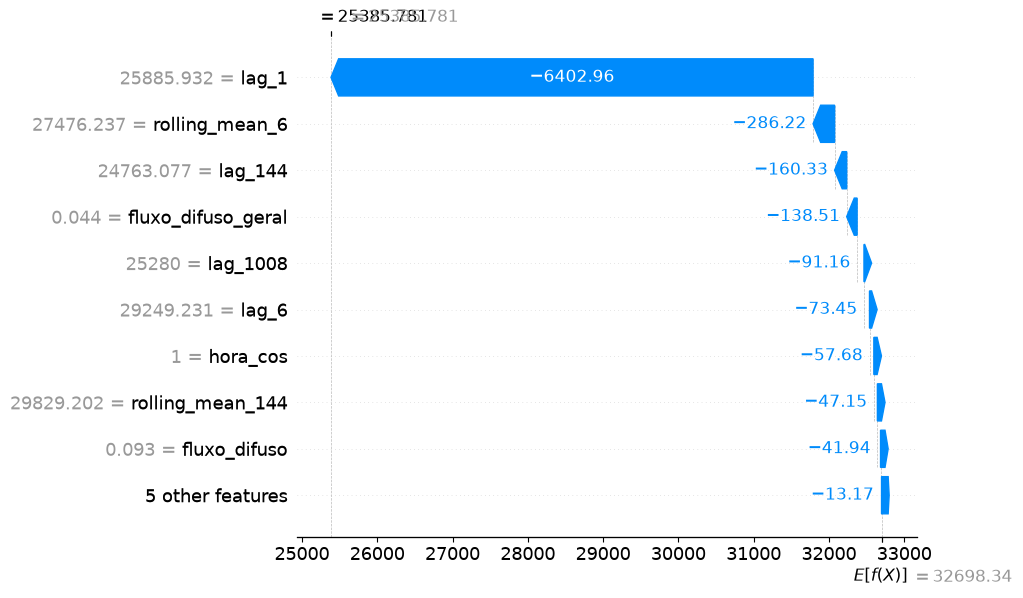

In [49]:
indice_consumo = 3

consumo_df = X_teste_final.iloc[[indice_consumo]]

valor_real = y_teste_final.iloc[indice_consumo]
valor_previsto = modelo_final.predict(consumo_df)[0]

print(f"Valor Real -> {valor_real:.2f}")
print(f"Valor Previsto -> {valor_previsto:.2f}")

shap.plots.waterfall(
    shap_values[indice_consumo]
)

# 14. Aplicação do Modelo e Forecast Mensal

Após a seleção e avaliação do XGBoost como modelo final, o modelo é treinado novamente utilizando todo o histórico disponível.

Nesta etapa, é realizada uma simulação do consumo energético para os próximos 30 dias.

Como o XGBoost utiliza lags e médias móveis, as previsões são geradas de forma recursiva: cada valor previsto passa a compor o histórico utilizado na previsão seguinte.

O horizonte de 30 dias corresponde a 4.320 intervalos de 10 minutos.

## 14.1 Treinamento com Todo o Histórico

Após a avaliação final, o XGBoost é treinado novamente utilizando todo o conjunto de dados disponível para modelagem.

O objetivo passa a ser utilizar todo o histórico conhecido para gerar previsões futuras.

In [60]:
X_total = dados_ml.drop(columns="consumo_zona_1")
y_total = dados_ml["consumo_zona_1"]

modelo_producao = xgb.XGBRegressor(
    **study_xgb.best_params,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

modelo_producao.fit(X_total, y_total)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9991105289762969
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## 14.2 Definição do Horizonte de Previsão

Como cada observação representa um intervalo de 10 minutos, um período de 30 dias corresponde a 4.320 previsões.

As datas futuras são criadas mantendo a mesma frequência temporal da série original.

In [61]:
horizonte = 4320

datas_futuras = pd.date_range(
    start=dados_ml.index.max() + pd.Timedelta(minutes=10),
    periods=horizonte,
    freq="10min"
)

print(f"Início -> {datas_futuras.min()}")
print(f"Fim -> {datas_futuras.max()}")
print(f"Previsões -> {len(datas_futuras)}")

Início -> 2017-12-31 00:00:00
Fim -> 2018-01-29 23:50:00
Previsões -> 4320


## 14.3 Cenário das Variáveis Meteorológicas

O XGBoost utiliza variáveis meteorológicas como temperatura, umidade, velocidade do vento e fluxos difusos.

Como essas informações não estão disponíveis para o período futuro, a aplicação utiliza os últimos 30 dias observados como cenário meteorológico para a simulação.

Em uma aplicação real, essas variáveis deveriam ser fornecidas por uma API ou serviço de previsão meteorológica.

In [62]:
variaveis_clima = [
    "temperatura",
    "umidade",
    "velocidade_vento",
    "fluxo_difuso_geral",
    "fluxo_difuso"
]

clima_futuro = (
    dados_ml[variaveis_clima]
    .iloc[-4320:]
    .copy()
)

clima_futuro.index = datas_futuras

## 14.4 Forecast dos Próximos 30 Dias

A previsão é realizada de forma recursiva.

Após cada previsão, o valor estimado é incorporado ao histórico e utilizado na construção dos lags e médias móveis necessários para prever o próximo intervalo.

In [63]:
historico = dados_ml["consumo_zona_1"].copy()

previsoes = []

In [65]:
for data_hora in datas_futuras:

    clima = clima_futuro.loc[data_hora]

    X_futuro = pd.DataFrame({
        "temperatura": [clima["temperatura"]],
        "umidade": [clima["umidade"]],
        "velocidade_vento": [clima["velocidade_vento"]],
        "fluxo_difuso_geral": [clima["fluxo_difuso_geral"]],
        "fluxo_difuso": [clima["fluxo_difuso"]],

        "lag_1": [historico.iloc[-1]],
        "lag_6": [historico.iloc[-6]],
        "lag_144": [historico.iloc[-144]],
        "lag_1008": [historico.iloc[-1008]],

        "rolling_mean_6": [historico.iloc[-6:].mean()],
        "rolling_mean_144": [historico.iloc[-144:].mean()],

        "dia_da_semana": [data_hora.dayofweek],

        "hora_sin": [
            np.sin(2 * np.pi * data_hora.hour / 24)
        ],

        "hora_cos": [
            np.cos(2 * np.pi * data_hora.hour / 24)
        ]
    }, index=[data_hora])

    # Mantém exatamente as mesmas features e ordem do treinamento
    X_futuro = X_futuro[X_total.columns]

    previsao = modelo_producao.predict(X_futuro)[0]

    previsoes.append(previsao)

    # A previsão passa a fazer parte do histórico
    historico.loc[data_hora] = previsao

In [66]:
forecast_df = pd.DataFrame(
    {
        "consumo_previsto": previsoes
    },
    index=datas_futuras
)

forecast_df.head()

,consumo_previsto
2017-12-31 00:00:00,27575.583984
2017-12-31 00:10:00,26975.642578
2017-12-31 00:20:00,26419.730469
2017-12-31 00:30:00,25843.498047
2017-12-31 00:40:00,25340.677734


## 14.5 Evolução do Consumo Previsto

Para facilitar a interpretação do horizonte mensal, as previsões de 10 minutos são agregadas em médias horárias.

O gráfico apresenta o comportamento observado no último mês e a projeção para os próximos 30 dias.

In [75]:
historico_horario = (
    dados_ml["consumo_zona_1"]
    .iloc[-4320:]
    .resample("D")
    .mean()
)

forecast_horario = (
    forecast_df["consumo_previsto"]
    .resample("D")
    .mean()
)

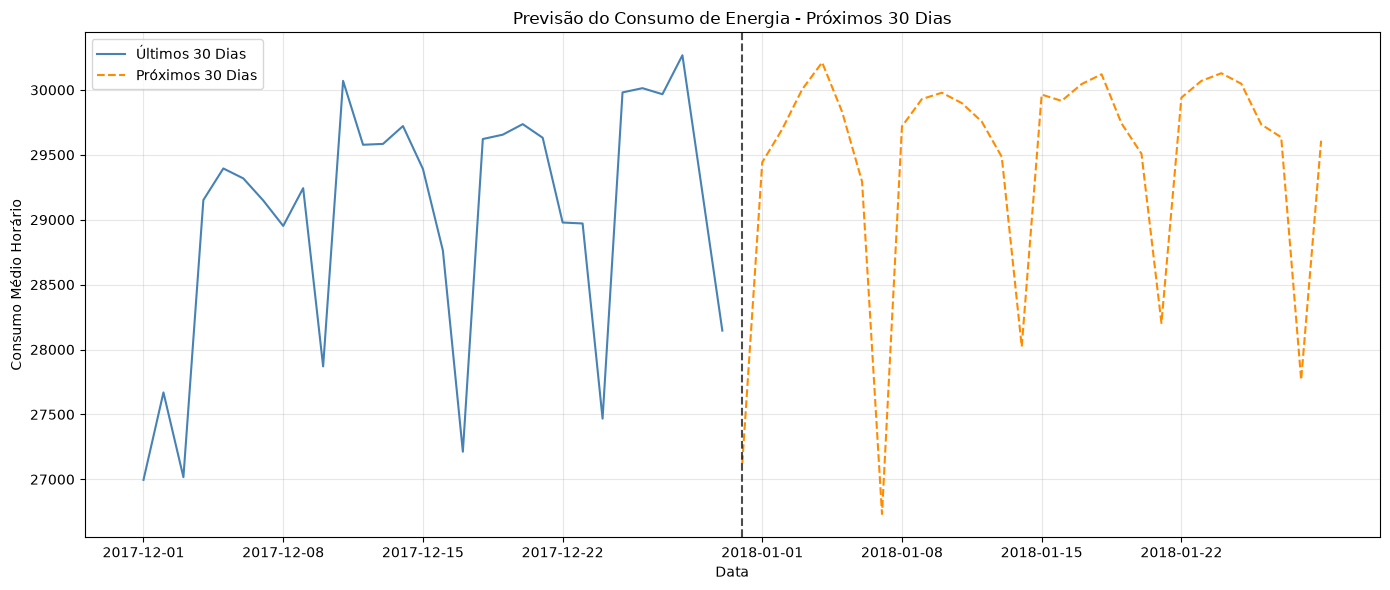

In [76]:
plt.figure(figsize=(14, 6))

plt.plot(
    historico_horario.index,
    historico_horario,
    label="Últimos 30 Dias",
    color="steelblue"
)

plt.plot(
    forecast_horario.index,
    forecast_horario,
    label="Próximos 30 Dias",
    color="darkorange",
    linestyle="--"
)

plt.axvline(
    dados_ml.index.max(),
    color="black",
    linestyle="--",
    alpha=0.7
)

plt.title("Previsão do Consumo de Energia - Próximos 30 Dias")
plt.xlabel("Data")
plt.ylabel("Consumo Médio Horário")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 14.6 Períodos de Maior e Menor Demanda

A partir das previsões são identificados os períodos de maior e menor consumo esperado durante o próximo mês.

In [69]:
data_max = forecast_df["consumo_previsto"].idxmax()
valor_max = forecast_df["consumo_previsto"].max()

data_min = forecast_df["consumo_previsto"].idxmin()
valor_min = forecast_df["consumo_previsto"].min()

print(
    f"Maior consumo previsto -> "
    f"{valor_max:.2f} em {data_max}"
)

print(
    f"Menor consumo previsto -> "
    f"{valor_min:.2f} em {data_min}"
)

Maior consumo previsto -> 41236.88 em 2018-01-04 18:40:00
Menor consumo previsto -> 15969.11 em 2018-01-07 07:40:00


## 14.7 Resumo da Previsão

Os principais indicadores do forecast são consolidados para fornecer uma visão resumida da demanda energética esperada para o próximo mês.

In [70]:
media_prevista = forecast_df["consumo_previsto"].mean()

resumo_forecast = pd.DataFrame({
    "Indicador": [
        "Consumo médio previsto",
        "Maior consumo previsto",
        "Menor consumo previsto"
    ],
    "Valor": [
        media_prevista,
        valor_max,
        valor_min
    ]
})

resumo_forecast.round(2)

,Indicador,Valor
0,Consumo médio previsto,29451.929688
1,Maior consumo previsto,41236.878906
2,Menor consumo previsto,15969.110352


## 14.8 Comparação com o Último Mês Observado

Para contextualizar a previsão, o consumo médio esperado para os próximos 30 dias é comparado com o consumo médio observado nos últimos 30 dias.

Essa análise permite identificar se o modelo projeta crescimento, redução ou estabilidade da demanda.

In [71]:
ultimo_mes = dados_ml["consumo_zona_1"].iloc[-4320:]

media_ultimo_mes = ultimo_mes.mean()
media_proximo_mes = forecast_df["consumo_previsto"].mean()

variacao_absoluta = (
    media_proximo_mes - media_ultimo_mes
)

variacao_percentual = (
    variacao_absoluta / media_ultimo_mes
) * 100

In [72]:
print(f"Média último mês -> {media_ultimo_mes:.2f}")
print(f"Média próximo mês -> {media_proximo_mes:.2f}")
print(f"Variação absoluta -> {variacao_absoluta:.2f}")
print(f"Variação percentual -> {variacao_percentual:.2f}%")

Média último mês -> 29024.17
Média próximo mês -> 29451.93
Variação absoluta -> 427.76
Variação percentual -> 1.47%


In [73]:
comparacao_mensal = pd.DataFrame({
    "Período": [
        "Últimos 30 Dias",
        "Próximos 30 Dias"
    ],
    "Consumo Médio": [
        media_ultimo_mes,
        media_proximo_mes
    ]
})

comparacao_mensal.round(2)

,Período,Consumo Médio
0,Últimos 30 Dias,29024.17
1,Próximos 30 Dias,29451.93


# 15. Pipeline do Modelo

In [77]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [78]:
X_total = dados_ml.drop(columns="consumo_zona_1")
y_total = dados_ml["consumo_zona_1"]

In [79]:
features_numericas = X_total.select_dtypes(include=np.number).columns.tolist()

print(f"Features Numéricas -> {features_numericas}")

Features Numéricas -> ['temperatura', 'umidade', 'velocidade_vento', 'fluxo_difuso_geral', 'fluxo_difuso', 'lag_1', 'lag_6', 'lag_144', 'lag_1008', 'rolling_mean_6', 'rolling_mean_144', 'dia_da_semana', 'hora_sin', 'hora_cos']


In [80]:
pipeline_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("modelo_final", modelo_final)
])

In [81]:
pipeline_final.fit(X_treino, y_treino)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('modelo_final', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['temperatura','umidade','velocidade_vento',...,'dia_da_semana','hora_sin', 'hora_cos']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or 

In [82]:
amostra = X_total.iloc[[-1]]

previsao = pipeline_final.predict(amostra)[0]

print(f"Valor previsto -> {previsao:.2f}")

Valor previsto -> 28193.98


In [83]:
# salvando o Pipeline Final
joblib.dump(pipeline_final, "../models/pipeline_final.pkl")

['../models/pipeline_final.pkl']